# Functional Data — Exploratory Analysis

**Goal.** Build a clear, ground-truth picture of the structure of the
MICrONS functional dataset (`data/functional/microns_functional.h5`) so that
every downstream design choice (feature extraction, train/test splits,
classifier inputs) sits on a verified understanding of the data.

This notebook does **not** depend on `microns-datacleaner` for the schema
exploration — it reads the H5 directly, which is faster and removes any
ambiguity coming from the cleaner's higher-level API.

---

## Questions answered here

1. **What is a "time series" in this dataset?** Is it one per session-scan,
   one per trial, one per (neuron, trial)?
2. **How long is each time series?** Frames, seconds, sampling rate. Do all
   trials have the same length, or does length depend on the stimulus?
3. **Are the same neurons recorded across multiple session-scans?** What
   does it mean to compare "the same unit" across sessions?
4. **Is the trial sequence (sequence of `condition_hashes`) the same in
   every session, or unique per session?** How many conditions are shared
   across sessions ("oracle") vs. session-specific?
5. **How many condition hashes belong to each stimulus family** (`Clip`,
   `Monet2`, `Trippy`)?
6. **Do we have the stimuli themselves as time series** (pixel-level video),
   and at what sampling rate are they aligned to the neural responses?
7. **What behavioural signals come along with the responses** (pupil,
   treadmill)?


## 1. Setup


In [1]:
# Standard scientific stack
import os
from pathlib import Path
from collections import Counter
import urllib.parse

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)


In [2]:
# Path to the functional H5. The file is ~20 GB and lives outside this folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'katia' else Path.cwd()
H5_PATH = Path('data/functional/microns_functional.h5')
assert H5_PATH.exists(), f'Functional H5 not found at {H5_PATH.resolve()}'

print('H5 path:', H5_PATH.resolve())
print('Size: %.2f GB' % (H5_PATH.stat().st_size / 1e9))


H5 path: /Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/katia/data/functional/microns_functional.h5
Size: 20.64 GB


---
## 2. H5 schema at a glance

The file has four top-level groups:

| group | contents |
|-------|----------|
| `brain_areas/` | one entry per area (V1, LM, AL, RL) — purely a registry |
| `sessions/`   | the actual recordings: one entry per session-scan (e.g. `4_7`) |
| `types/`      | maps stimulus type (`Clip`, `Monet2`, `Trippy`) → set of condition hashes |
| `videos/`     | one entry per stimulus condition: pixel data + per-instance traces |

We confirm this on the actual file below.


In [3]:
def describe_group(g, depth=0, max_depth=2, max_per_level=6, indent='  '):
    """Recursively print group structure with shapes/dtypes for datasets."""
    keys = list(g.keys())
    print(indent * depth + f'{g.name}/  ({len(keys)} children)')
    for k in keys[:max_per_level]:
        v = g[k]
        if isinstance(v, h5py.Group):
            if depth + 1 <= max_depth:
                describe_group(v, depth + 1, max_depth, max_per_level, indent)
            else:
                print(indent * (depth + 1) + f'{k}/  ({len(list(v.keys()))} children)')
        else:
            print(indent * (depth + 1) + f'{k}  shape={v.shape} dtype={v.dtype}')
    if len(keys) > max_per_level:
        print(indent * (depth + 1) + f'... ({len(keys) - max_per_level} more)')

with h5py.File(H5_PATH, 'r') as f:
    print('Top-level groups:', list(f.keys()))
    print()
    describe_group(f, max_depth=1, max_per_level=4)


Top-level groups: ['brain_areas', 'sessions', 'types', 'videos']

//  (4 children)
  /brain_areas/  (4 children)
    AL/  (14 children)
    LM/  (14 children)
    RL/  (14 children)
    V1/  (14 children)
  /sessions/  (14 children)
    4_7/  (2 children)
    5_6/  (2 children)
    5_7/  (2 children)
    6_2/  (2 children)
    ... (10 more)
  /types/  (3 children)
    Clip/  (2112 children)
    Monet2/  (150 children)
    Trippy/  (149 children)
  /videos/  (2411 children)
    %2F0MJJl6hCzFo3gxCJSmv/  (3 children)
    %2F3cVqNzav4cRdcLPJXWr/  (3 children)
    %2F5KYggaBDxG7uxMGf589/  (3 children)
    %2F5lWcH4KIogPpGKGfScG/  (3 children)
    ... (2407 more)


---
## 3. Sessions inventory

How many session-scans are there, and how many recorded units does each one
contain (split by brain area)?


In [4]:
with h5py.File(H5_PATH, 'r') as f:
    rows = []
    for sess in sorted(f['sessions'].keys()):
        meta = f['sessions'][sess]['meta']
        n_units_total = meta['unit_ids'].shape[0]
        n_trials = len(f['sessions'][sess]['trials'])
        ai = meta['area_indices']
        row = {
            'session_scan': sess,
            'session': int(sess.split('_')[0]),
            'scan_idx': int(sess.split('_')[1]),
            'n_units': n_units_total,
            'n_trials': n_trials,
            'n_V1': ai['V1'].shape[0],
            'n_LM': ai['LM'].shape[0],
            'n_AL': ai['AL'].shape[0],
            'n_RL': ai['RL'].shape[0],
        }
        rows.append(row)

sessions_df = pd.DataFrame(rows).sort_values('session_scan').reset_index(drop=True)
sessions_df


,session_scan,session,scan_idx,n_units,n_trials,n_V1,n_LM,n_AL,n_RL
0,4_7,4,7,7493,464,5312,983,387,811
1,5_6,5,6,8592,464,6014,1158,468,952
2,5_7,5,7,8138,464,5777,1066,403,892
3,6_2,6,2,8158,464,6002,978,317,861
4,6_4,6,4,8221,464,5999,1027,317,878
5,6_6,6,6,7971,464,5905,979,287,800
6,6_7,6,7,7887,464,5808,960,305,814
7,7_3,7,3,8618,464,6309,1135,324,850
8,7_4,7,4,11201,464,7725,1534,575,1367
9,7_5,7,5,8194,464,5485,1262,414,1033


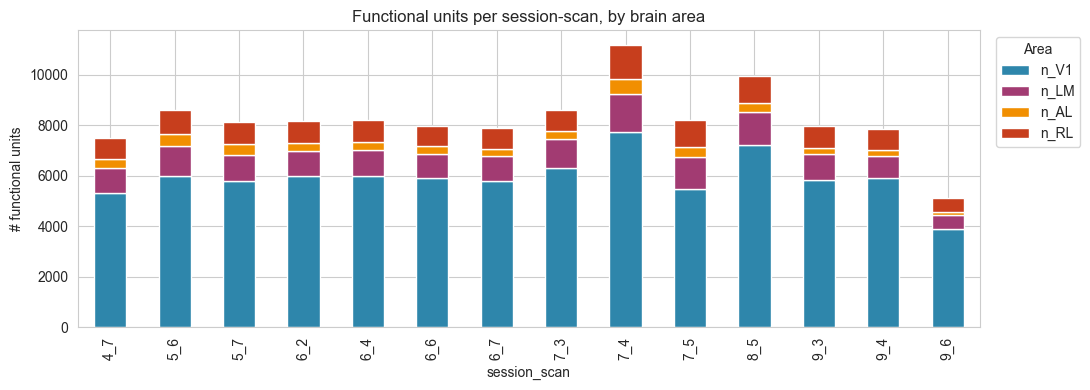

In [5]:
# Visualize per-session area composition.
fig, ax = plt.subplots(figsize=(11, 4))
sessions_df.set_index('session_scan')[['n_V1', 'n_LM', 'n_AL', 'n_RL']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'],
)
ax.set_ylabel('# functional units')
ax.set_title('Functional units per session-scan, by brain area')
ax.legend(title='Area', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Takeaway.** 14 session-scans. Every session contains units from all 4
areas, with V1 dominating (typical V1 share ≈ 65–80% of units in a scan).
Total units per scan ranges roughly 5 000 – 11 000.


---
## 4. Q1 + Q2 — What is a "time series" and how long is it?

Inside a session-scan we have `trials/0`, `trials/1`, ..., `trials/463` — i.e.
**464 trials per session-scan**. A single trial group looks like this:

```
sessions/<sess>/trials/<trial_id>/
├── responses    (n_units, n_frames)   float32   ← calcium responses
├── stim_times   (n_frames,)           float32   ← timestamp per frame (s)
├── pupil        (4, n_frames)         float32   ← pupil tracking
└── treadmill    (n_frames, 1)         float32   ← running speed
```

So the **fundamental time series is per `(neuron, trial)`** — for each unit
and each trial we have one calcium trace of length `n_frames`. Per
session-scan a single neuron therefore has **464 time series** (one per
trial), not one continuous recording.

Below we confirm this empirically and measure trial lengths.


In [6]:
# Inspect one trial in detail.
SAMPLE_SESS = '4_7'
SAMPLE_TRIAL = '0'

with h5py.File(H5_PATH, 'r') as f:
    tr = f['sessions'][SAMPLE_SESS]['trials'][SAMPLE_TRIAL]
    print(f'Session {SAMPLE_SESS}, trial {SAMPLE_TRIAL}:')
    for k in tr.keys():
        v = tr[k]
        print(f'  {k}: shape={v.shape} dtype={v.dtype}')
    n_units = tr['responses'].shape[0]
    n_frames = tr['responses'].shape[1]
    print(f'\n=> {n_units} neurons × {n_frames} frames in this single trial')


Session 4_7, trial 0:
  pupil: shape=(4, 75) dtype=float32
  responses: shape=(7493, 75) dtype=float32
  stim_times: shape=(75,) dtype=float32
  treadmill: shape=(75, 1) dtype=float32

=> 7493 neurons × 75 frames in this single trial


In [7]:
# Trial-length distribution within one session: do all trials have the same length?
with h5py.File(H5_PATH, 'r') as f:
    trial_keys = sorted(f['sessions'][SAMPLE_SESS]['trials'].keys(), key=int)
    n_frames_list = [
        f['sessions'][SAMPLE_SESS]['trials'][tk]['responses'].shape[1]
        for tk in trial_keys
    ]

print(f'Frame-count distribution for {SAMPLE_SESS}:', Counter(n_frames_list))
print(f'Total trials: {len(n_frames_list)}')


Frame-count distribution for 4_7: Counter({75: 384, 113: 80})
Total trials: 464


In [8]:
# Estimate sampling rate (Hz) from stim_times.
with h5py.File(H5_PATH, 'r') as f:
    tr = f['sessions'][SAMPLE_SESS]['trials']['0']
    st = tr['stim_times'][:]

dt = np.diff(st)
fps = 1.0 / dt.mean()
duration = st[-1] - st[0]
print(f'Trial 0 of {SAMPLE_SESS}:')
print(f'  duration = {duration:.3f} s')
print(f'  mean Δt  = {dt.mean()*1000:.2f} ms  →  fps ≈ {fps:.2f} Hz')
print(f'  Δt std   = {dt.std()*1000:.3f} ms (regularity check)')


Trial 0 of 4_7:
  duration = 9.867 s
  mean Δt  = 133.33 ms  →  fps ≈ 7.50 Hz
  Δt std   = 0.007 ms (regularity check)


**Takeaway (so far).** Trials in one session have a
*bimodal* length: **75 frames** or **113 frames**. Calcium imaging is
sampled at ≈ 7.5 Hz. So each individual time series is either ≈ 10 s long
(75 frames) or ≈ 15 s long (113 frames). The next section ties this to the
stimulus.


---
## 5. Q5 — Stimulus families and how many conditions in each

The `types/` group splits all condition hashes by stimulus family:

- **`Clip`**   — natural movies (cinematic, rendered, sports)
- **`Monet2`** — parametric drifting orientation noise
- **`Trippy`** — parametric phase noise

Below we count hashes in each family and verify they are mutually
exclusive.


In [9]:
with h5py.File(H5_PATH, 'r') as f:
    type_sets = {t: set(f['types'][t].keys()) for t in f['types'].keys()}

type_counts = pd.Series({t: len(s) for t, s in type_sets.items()})
print('Unique condition hashes per stimulus family:')
print(type_counts)
print(f'\nTotal across families: {type_counts.sum()}')

# Check mutual exclusivity.
overlaps = {
    f'{a} ∩ {b}': len(type_sets[a] & type_sets[b])
    for a in type_sets for b in type_sets if a < b
}
print('\nPairwise overlaps:', overlaps)


Unique condition hashes per stimulus family:
Clip      2112
Monet2     150
Trippy     149
dtype: int64

Total across families: 2411

Pairwise overlaps: {'Clip ∩ Monet2': 0, 'Clip ∩ Trippy': 0, 'Monet2 ∩ Trippy': 0}


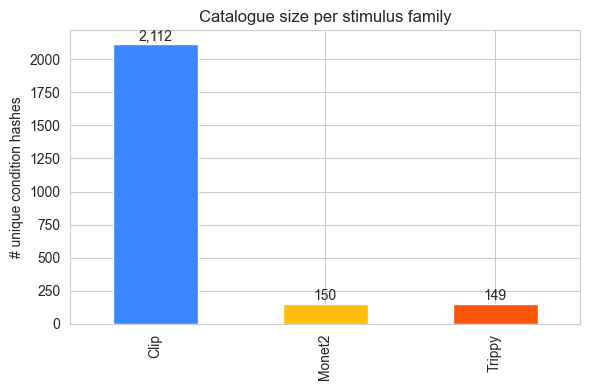

In [10]:
# Visualize.
fig, ax = plt.subplots(figsize=(6, 4))
type_counts.plot(kind='bar', ax=ax,
                 color=['#3a86ff', '#ffbe0b', '#fb5607'])
ax.set_ylabel('# unique condition hashes')
ax.set_title('Catalogue size per stimulus family')
for i, v in enumerate(type_counts.values):
    ax.text(i, v + 30, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


**Takeaway.** The stimulus library has **2 411** unique conditions in
total: 2 112 Clip + 150 Monet2 + 149 Trippy. Families are mutually
exclusive — every condition hash belongs to exactly one family.


---
## 6. Q6 — Do we have the stimuli themselves as time series?

Yes — each unique condition lives in `videos/<hash>/` with:

```
videos/<hash>/
├── clip       (n_frames, H, W)   uint8     ← downsampled to calcium-rate
├── times      (n_frames,)        float32   ← seconds
└── instances  (group)            ← one sub-group per (session, trial) the
                                    stimulus appeared in, mirroring the
                                    response/pupil/treadmill arrays
```

Two important details:

1. The **video frame count matches the calcium frame count** of the
   corresponding trials (75 for Clip, 113 for Monet2/Trippy). The original
   movies were recorded at 30 fps (Clip) or 60 fps (Monet/Trippy) but the
   stored `clip` is already aligned to the calcium sampling grid.
2. The **spatial dimensions differ by family**:
   Clip = 144×256, Monet2 = 126×216, Trippy = 90×160.


In [11]:
# Inspect one example per stimulus family.
with h5py.File(H5_PATH, 'r') as f:
    rows = []
    for stim_type in ['Clip', 'Monet2', 'Trippy']:
        sample_hash = next(iter(f['types'][stim_type].keys()))
        v = f['videos'][sample_hash]
        rows.append({
            'family': stim_type,
            'clip_shape': str(v['clip'].shape),
            'times_len': v['times'].shape[0],
            'duration_s': v.attrs.get('duration', np.nan),
            'orig_fps': v.attrs.get('fps', np.nan),
            'extra_attrs': {k: v.attrs[k] for k in v.attrs.keys()
                            if k not in ('duration', 'fps', 'type', 'original_hash')},
        })

stim_video_df = pd.DataFrame(rows)
stim_video_df


,family,clip_shape,times_len,duration_s,orig_fps,extra_attrs
0,Clip,"(75, 144, 256)",75,10.0,30.0,{'movie_name': 'ancienttomb_100-1-4-70-0_34.20...
1,Monet2,"(113, 126, 216)",113,15.0,60.0,{'ori_coherence': 2.5}
2,Trippy,"(113, 90, 160)",113,15.0,60.0,"{'spatial_freq': 0.08, 'temp_freq': 4.0}"


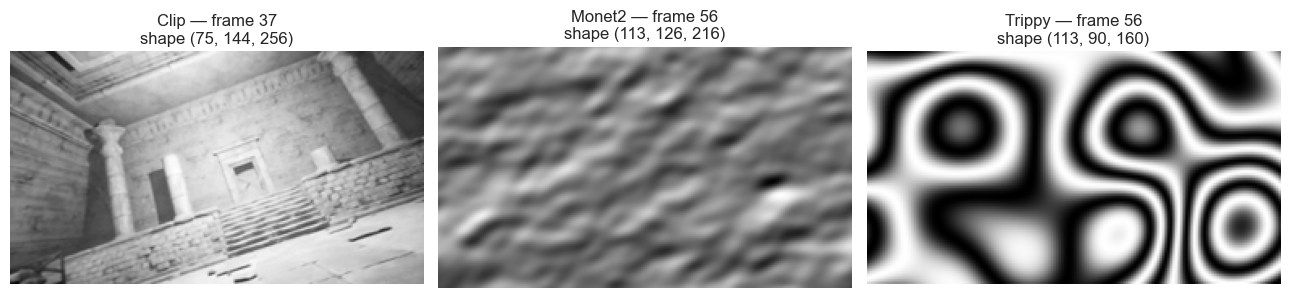

In [12]:
# Visualise one frame from each family.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
with h5py.File(H5_PATH, 'r') as f:
    for ax, stim_type in zip(axes, ['Clip', 'Monet2', 'Trippy']):
        sample_hash = next(iter(f['types'][stim_type].keys()))
        clip = f['videos'][sample_hash]['clip']
        ax.imshow(clip[clip.shape[0] // 2], cmap='gray')
        ax.set_title(f'{stim_type} — frame {clip.shape[0]//2}\nshape {clip.shape}')
        ax.axis('off')
plt.tight_layout()
plt.show()


---
## 7. Q4 — Trial sequence: same across sessions or unique?

Each session-scan stores `meta/condition_hashes` of length 464 — the
sequence of condition hashes shown trial-by-trial. We answer three nested
questions:

1. Are sequences identical across sessions? (i.e. did each animal see the
   same trials in the same order?)
2. How many *distinct* conditions does a session use, and how many times
   does each repeat within a session?
3. Across sessions: how many conditions are shared, vs. session-specific?

Note on encoding: `condition_hashes` is stored **raw** (e.g. `"/abc..."`,
`"+def..."`), but `types/X/...` and `videos/...` keys URL-encode `/` → `%2F`
while leaving `+` alone. The right round-trip is therefore
`urllib.parse.quote(h, safe='+')`.


In [13]:
def encode_hash(raw_hash: str) -> str:
    """Convert a raw condition_hash into the form used as a key in
    types/<stim_type>/<key> and videos/<key>."""
    return urllib.parse.quote(raw_hash, safe='+')

# Build raw_hash -> stim_type lookup once.
with h5py.File(H5_PATH, 'r') as f:
    enc2type = {}
    for stim_type in f['types'].keys():
        for h in f['types'][stim_type].keys():
            enc2type[h] = stim_type

def hash_to_type(raw_hash: str) -> str:
    return enc2type.get(encode_hash(raw_hash), 'UNK')

# Sanity check on one session.
with h5py.File(H5_PATH, 'r') as f:
    raw = f['sessions'][SAMPLE_SESS]['meta']['condition_hashes'][:]
    raw = [c.decode() if isinstance(c, (bytes, bytearray)) else c for c in raw]

types_in_seq = [hash_to_type(h) for h in raw]
print(f'{SAMPLE_SESS}: {len(raw)} trials')
print('Stimulus mix in trial sequence:', Counter(types_in_seq))


4_7: 464 trials
Stimulus mix in trial sequence: Counter({'Clip': 384, 'Monet2': 40, 'Trippy': 40})


In [14]:
# Per-session: trial-sequence breakdown by stimulus family.
with h5py.File(H5_PATH, 'r') as f:
    rows = []
    seqs = {}  # session -> tuple of raw hashes (the full ordering)
    for sess in sorted(f['sessions'].keys()):
        raw = f['sessions'][sess]['meta']['condition_hashes'][:]
        raw = tuple(c.decode() if isinstance(c, (bytes, bytearray)) else c for c in raw)
        seqs[sess] = raw
        cnt = Counter(hash_to_type(h) for h in raw)
        rows.append({
            'session_scan': sess,
            'n_trials': len(raw),
            'n_unique_conditions': len(set(raw)),
            'Clip': cnt.get('Clip', 0),
            'Monet2': cnt.get('Monet2', 0),
            'Trippy': cnt.get('Trippy', 0),
            'UNK': cnt.get('UNK', 0),
        })

trial_breakdown = pd.DataFrame(rows)
trial_breakdown


,session_scan,n_trials,n_unique_conditions,Clip,Monet2,Trippy,UNK
0,4_7,464,280,384,40,40,0
1,5_6,464,280,384,40,40,0
2,5_7,464,280,384,40,40,0
3,6_2,464,280,384,40,40,0
4,6_4,464,280,384,40,40,0
5,6_6,464,280,384,40,40,0
6,6_7,464,280,384,40,40,0
7,7_3,464,280,384,40,40,0
8,7_4,464,280,384,40,40,0
9,7_5,464,280,384,40,40,0


In [15]:
# Are the trial *sequences* (order of hashes) identical across any pair of sessions?
seq_hashes = {sess: hash(seqs[sess]) for sess in seqs}
n_distinct_orderings = len(set(seq_hashes.values()))
print(f'Distinct trial orderings across {len(seqs)} sessions: {n_distinct_orderings}')

# Overlap of *sets* of conditions across sessions.
sess_keys = sorted(seqs.keys())
sess_unique = {s: set(seqs[s]) for s in sess_keys}

overlap = pd.DataFrame(
    {a: [len(sess_unique[a] & sess_unique[b]) for b in sess_keys] for a in sess_keys},
    index=sess_keys
)
print('\nPairwise condition-set overlap (subset; full table available as overlap):')
print(overlap.iloc[:7, :7])


Distinct trial orderings across 14 sessions: 14

Pairwise condition-set overlap (subset; full table available as overlap):
     4_7  5_6  5_7  6_2  6_4  6_6  6_7
4_7  280  116  116  116  116  116  116
5_6  116  280  116  116  116  116  116
5_7  116  116  280  116  116  116  116
6_2  116  116  116  280  116  116  116
6_4  116  116  116  116  280  116  116
6_6  116  116  116  116  116  280  116
6_7  116  116  116  116  116  116  280


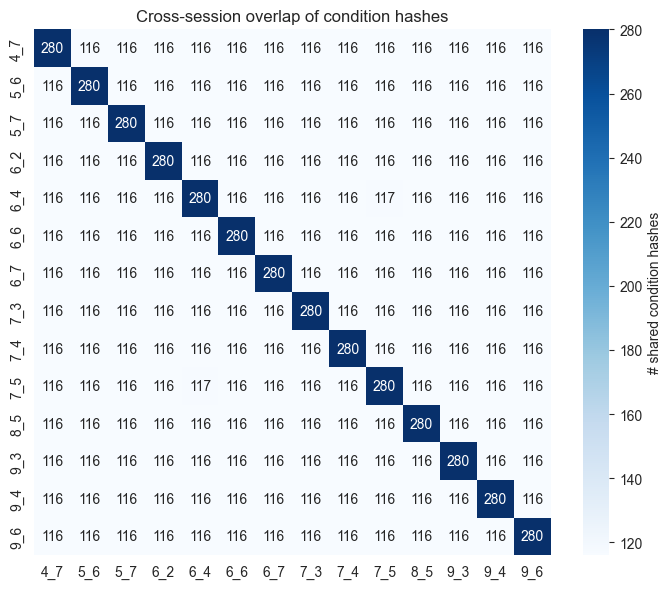

In [16]:
# Heatmap of overlap.
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(overlap, annot=True, fmt='d', cmap='Blues', ax=ax,
            cbar_kws={'label': '# shared condition hashes'})
ax.set_title('Cross-session overlap of condition hashes')
plt.tight_layout()
plt.show()


In [17]:
# How many sessions does each unique hash appear in?
hash_session_count = Counter()
for sess in sess_keys:
    for h in sess_unique[sess]:
        hash_session_count[h] += 1

dist = Counter(hash_session_count.values())
print('Distribution: hash -> # sessions it appears in')
for k in sorted(dist):
    print(f'  in {k:>2} session(s): {dist[k]:>5} hashes')

oracle_hashes = [h for h, c in hash_session_count.items() if c == len(sess_keys)]
print(f'\nOracle conditions (in all {len(sess_keys)} sessions): {len(oracle_hashes)}')
print('  by stimulus family:', Counter(hash_to_type(h) for h in oracle_hashes))


Distribution: hash -> # sessions it appears in
  in  1 session(s):  2294 hashes
  in  2 session(s):     1 hashes
  in 14 session(s):   116 hashes

Oracle conditions (in all 14 sessions): 116
  by stimulus family: Counter({'Clip': 96, 'Trippy': 10, 'Monet2': 10})


In [18]:
# Within a session: how many times does each unique condition repeat,
# broken down by stimulus family?
def repeats_by_family(sess):
    raw = seqs[sess]
    counts = Counter(raw)
    out = {'Clip': [], 'Monet2': [], 'Trippy': [], 'UNK': []}
    for h, c in counts.items():
        out[hash_to_type(h)].append(c)
    return out

repeats = repeats_by_family(SAMPLE_SESS)
print(f'Within {SAMPLE_SESS}, repeats per unique hash by stimulus family:')
for t in ['Clip', 'Monet2', 'Trippy']:
    print(f'  {t:<6}: {dict(Counter(repeats[t]))}  '
          f'(n_unique={len(repeats[t])}, n_total={sum(repeats[t])})')


Within 4_7, repeats per unique hash by stimulus family:
  Clip  : {1: 144, 2: 90, 10: 6}  (n_unique=240, n_total=384)
  Monet2: {2: 20}  (n_unique=20, n_total=40)
  Trippy: {2: 20}  (n_unique=20, n_total=40)


**Takeaways for the trial structure.**

- All 14 sessions have **464 trials** and **280 unique conditions** each,
  but no two sessions share the same trial ordering — each session-scan was
  presented with its **own randomized sequence**.
- Within a session the family mix is **~384 Clip · ~40 Monet2 · ~40 Trippy**
  trials (≈ 83% / 8.5% / 8.5%).
- **116 conditions are shown in every session** ("oracle" set, used for
  cross-session decoding / generalization tests): 96 Clip + 10 Monet2 +
  10 Trippy. The remaining ~164 conditions in each session are
  session-specific.
- Within a session, most Clip conditions appear once or twice, while every
  Monet2 / Trippy condition appears exactly twice. Oracle Clip conditions
  appear ~10 times each — multiple repeats here are what allow clean
  trial-averaged "tuning" features.
- All 464 hashes resolve to a stimulus family — provided the lookup uses
  `urllib.parse.quote(h, safe='+')` (only `/` is URL-encoded in the
  `types/` and `videos/` keys, `+` is not).


---
## 8. Q3 — Same neurons across session-scans?

The H5 stores `unit_ids` per session. Two important caveats:

- The same numeric `unit_id` can appear in different sessions, but **that
  does *not* mean the same biological neuron**. The H5 alone does not
  uniquely identify a neuron across scans.
- Cross-scan neuron identity comes from the **structural data**: every
  matched neuron has a `nucleus_id`, and `microns-datacleaner`'s `match`
  mode produces a `(nucleus_id, session, scan_idx, unit_id)` table that
  links each session-scan record back to the biological neuron.

Below we just measure the raw `unit_id` overlap as an upper bound and flag
that the proper analysis must use `nucleus_id`.


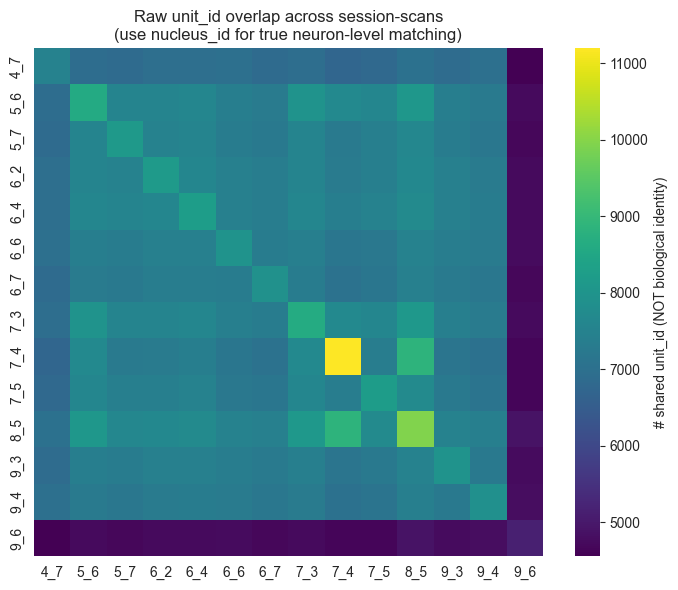

In [19]:
# Raw unit_id overlap (UPPER BOUND, not biological identity).
with h5py.File(H5_PATH, 'r') as f:
    sess_units = {sess: set(int(u) for u in f['sessions'][sess]['meta']['unit_ids'][:])
                  for sess in sorted(f['sessions'].keys())}

uoverlap = pd.DataFrame(
    {a: [len(sess_units[a] & sess_units[b]) for b in sess_units] for a in sess_units},
    index=list(sess_units),
)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(uoverlap, annot=False, cmap='viridis', ax=ax,
            cbar_kws={'label': '# shared unit_id (NOT biological identity)'})
ax.set_title('Raw unit_id overlap across session-scans\n'
             '(use nucleus_id for true neuron-level matching)')
plt.tight_layout()
plt.show()


**Action item for downstream phases.** When asking *"is neuron X in scan
A also in scan B?"*, do **not** rely on `unit_id` alone — join through
`nucleus_id` from the structural metadata produced by
`microns_datacleaner.MicronsDataCleaner.process_nucleus_data(functional_data='match')`.


---
## 9. A quick look at one trace and the behavioural signals

Pulling one trial of one V1 neuron, plus the pupil/treadmill traces, just
to make the data tangible.


Trial 5 | stim type = Clip | n_frames = 75


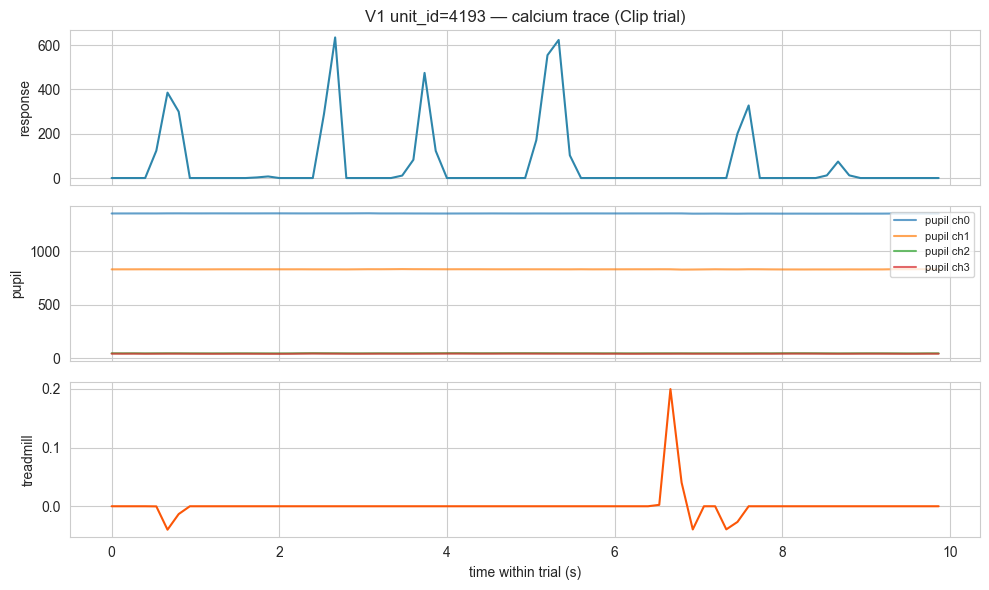

In [20]:
SAMPLE_SESS = '4_7'
SAMPLE_TRIAL = '5'  # not trial 0 — first trial sometimes has a longer stim onset

with h5py.File(H5_PATH, 'r') as f:
    tr = f['sessions'][SAMPLE_SESS]['trials'][SAMPLE_TRIAL]
    resp = tr['responses'][:]              # (n_units, n_frames)
    pup = tr['pupil'][:]                   # (4, n_frames)
    tread = tr['treadmill'][:].squeeze()   # (n_frames,)
    st = tr['stim_times'][:]
    st = st - st[0]                        # zero at trial onset

    raw_hash = f['sessions'][SAMPLE_SESS]['meta']['condition_hashes'][int(SAMPLE_TRIAL)]
    raw_hash = raw_hash.decode() if isinstance(raw_hash, (bytes, bytearray)) else raw_hash
    stim_type = hash_to_type(raw_hash)

    # Pick one V1 neuron with non-trivial response in this trial.
    v1_idx = f['sessions'][SAMPLE_SESS]['meta']['area_indices']['V1'][:]
    v1_var = resp[v1_idx].var(axis=1)
    chosen = v1_idx[np.argsort(-v1_var)[3]]   # 4th most variable V1 neuron in this trial

print(f'Trial {SAMPLE_TRIAL} | stim type = {stim_type} | n_frames = {resp.shape[1]}')

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].plot(st, resp[chosen], color='#2E86AB')
axes[0].set_ylabel('response')
axes[0].set_title(f'V1 unit_id={chosen} — calcium trace ({stim_type} trial)')

for ch in range(pup.shape[0]):
    axes[1].plot(st, pup[ch], alpha=0.7, label=f'pupil ch{ch}')
axes[1].set_ylabel('pupil')
axes[1].legend(loc='upper right', fontsize=8)

axes[2].plot(st, tread, color='#fb5607')
axes[2].set_ylabel('treadmill')
axes[2].set_xlabel('time within trial (s)')

plt.tight_layout()
plt.show()


---
## 10. Summary — direct answers

| # | Question | Answer |
|---|----------|--------|
| 1 | What is one "time series"? | A `(neuron, trial)` calcium trace. Per session-scan a neuron has 464 traces (one per trial), **not** one continuous recording. |
| 2 | How long is a time series? | **75 frames** (Clip, ≈10 s) or **113 frames** (Monet2 / Trippy, ≈15 s) at ≈ **7.5 Hz**. |
| 3 | Trials per session-scan? | Always **464**. |
| 4 | Condition variety per session-scan? | **280** unique condition hashes per session-scan, distributed as **~240 Clip + 20 Monet2 + 20 Trippy**, played out over 464 trials. |
| 5 | Same trial sequence across sessions? | **No.** All 14 sessions have a different randomized ordering. **116** conditions are shared across *all* sessions ("oracle": 96 Clip + 10 Monet2 + 10 Trippy); the rest are session-specific. |
| 6 | # condition hashes per stimulus family? | **Clip 2 112 · Monet2 150 · Trippy 149** (total 2 411, mutually exclusive). |
| 7 | Stimuli as time series? | Yes — `videos/<hash>/clip` of shape `(n_frames, H, W)`, already aligned to the calcium frame rate (75 / 113 frames). H×W differs by family. |
| 8 | Behavioural signals? | Per trial: `pupil` (4, n_frames) and `treadmill` (n_frames, 1). Same time-base as `responses`. |
| 9 | Neuron identity across scans? | **Not** via `unit_id` (numeric overlaps are coincidental). Use `nucleus_id` from the structural metadata (`microns-datacleaner` match mode). |

### Implications for the classifier (CLAUDE.md research question)

- The natural input unit for a per-neuron classifier is **a 3-D tensor of
  shape `(n_trials, n_frames, ...)`** — and `n_frames` varies by stim
  family, so any architecture has to handle two trial lengths (or pad/crop
  uniformly per family, or process Clip / Monet2 / Trippy as separate
  streams).
- The 116 oracle conditions give a **clean cross-session axis**: features
  derived from the same stimuli regardless of which session a neuron was
  imaged in.
- The pre-computed 1024-dim foundation-model embedding mentioned in
  CLAUDE.md sidesteps the variable-length issue entirely; this notebook
  documents what we'd lose by not using it.
